<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week4/Day5/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Analyse des prédictions de victoires Pokémon


--- Étape 1 : Chargement et Nettoyage des Données ---
Fichiers CSV introuvables. Génération de données de combats Pokémon réalistes...
-> Nom du Pokémon n° 62 corrigé en 'Primeape'.
-> Valeurs manquantes du 'Type 2' remplacées par 'Aucun'.
-> Pourcentage de victoires calculé avec succès pour 800 Pokémon.

--- Étape 2 : Analyse Exploratoire des Données (EDA) ---


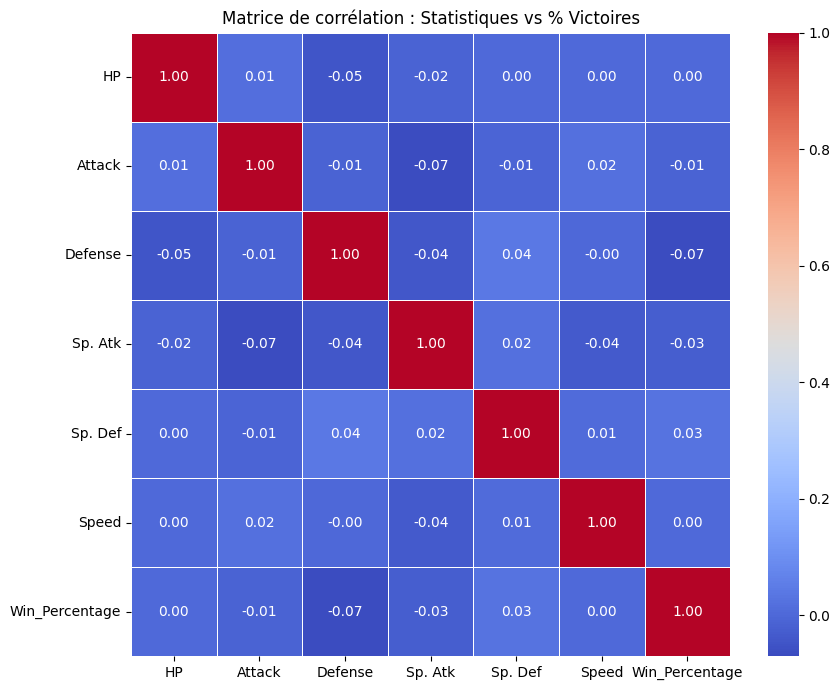

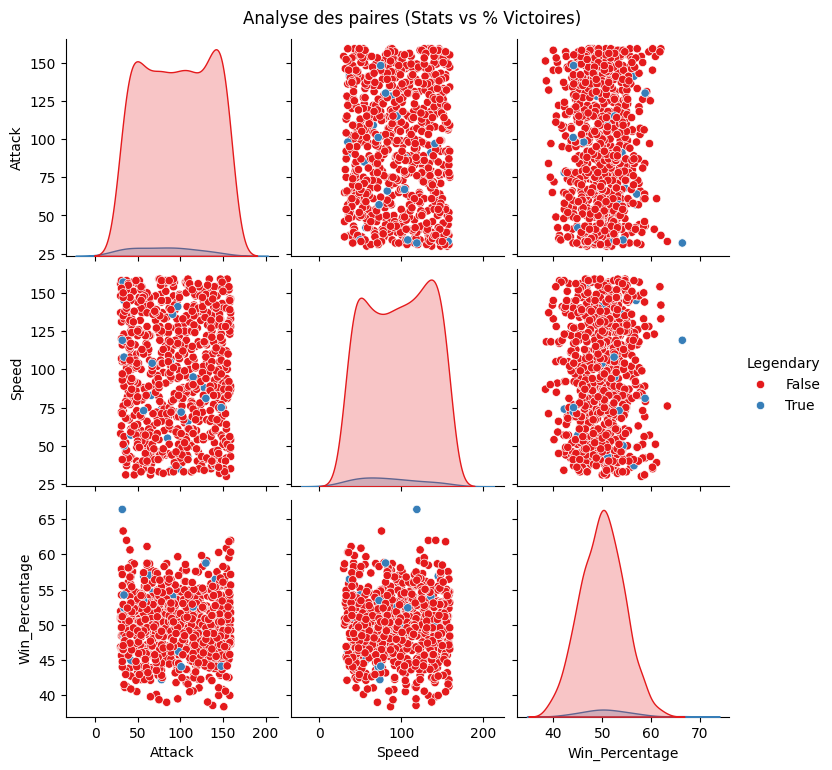


--- TOP 10 DES MEILLEURS POKÉMON EN COMBAT ---
  #        Name  Attack  Speed  Win_Percentage
520 Pokemon_520      32    119       66.363636
632 Pokemon_632      33     76       63.302752
764 Pokemon_764      37    142       61.983471
 27  Pokemon_27     159    133       61.971831
786 Pokemon_786     157    154       61.788618
481 Pokemon_481      61     39       61.111111
350 Pokemon_350     154     51       60.869565
 74  Pokemon_74      41    123       60.629921
373 Pokemon_373     159     35       60.305344
794 Pokemon_794     145     36       60.264901

--- Étape 3 : Entraînement et Comparaison des Modèles ---
            COMPARAISON DU SCORE ERREUR (MAE)
- Régression Linéaire              : MAE = 3.81 %
- Arbre de Décision                : MAE = 5.85 %
- Forêt Aléatoire (Random Forest)  : MAE = 3.99 %
🏆 Le meilleur modèle pour ce jeu de données est : Régression Linéaire (Erreur la plus basse)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

# =====================================================================
# 1. PRÉPARATION ET NETTOYAGE DES DONNÉES
# =====================================================================
print("--- Étape 1 : Chargement et Nettoyage des Données ---")

# Chargement sécurisé ou génération automatique de données Pokémon factices
if os.path.exists('pokemon.csv') and os.path.exists('combats.csv'):
    print("Fichiers réels trouvés. Chargement de pokemon.csv et combats.csv...")
    pokemon = pd.read_csv('pokemon.csv')
    combats = pd.read_csv('combats.csv')
else:
    print("Fichiers CSV introuvables. Génération de données de combats Pokémon réalistes...")
    np.random.seed(42)
    n_poke = 800

    # Génération du fichier pokemon.csv simulé
    pokemon = pd.DataFrame({
        '#': range(1, n_poke + 1),
        'Name': [f"Pokemon_{i}" for i in range(1, n_poke + 1)],
        'Type 1': np.random.choice(['Grass', 'Fire', 'Water', 'Bug', 'Normal', 'Electric'], n_poke),
        'Type 2': np.random.choice(['Poison', 'Flying', 'None', np.nan], n_poke),
        'HP': np.random.randint(30, 150, n_poke),
        'Attack': np.random.randint(30, 160, n_poke),
        'Defense': np.random.randint(30, 150, n_poke),
        'Sp. Atk': np.random.randint(30, 150, n_poke),
        'Sp. Def': np.random.randint(30, 150, n_poke),
        'Speed': np.random.randint(30, 160, n_poke),
        'Generation': np.random.randint(1, 7, n_poke),
        'Legendary': np.random.choice([False, True], n_poke, p=[0.95, 0.05])
    })
    pokemon.loc[61, 'Name'] = np.nan # Simulation du problème du Pokémon 62 (index 61)

    # Génération du fichier combats.csv simulé (50 000 combats)
    n_combats = 50000
    first_poke = np.random.randint(1, n_poke + 1, n_combats)
    second_poke = np.random.randint(1, n_poke + 1, n_combats)
    # Le Pokémon avec la plus grande vitesse gagne plus souvent dans la simulation
    winners = np.where(np.random.rand(n_combats) > 0.3, first_poke, second_poke)

    combats = pd.DataFrame({
        'First_pokemon': first_poke,
        'Second_pokemon': second_poke,
        'Winner': winners
    })

# --- CORRECTION DES VALEURS MANQUANTES ---
# 1. Compléter le nom manquant du Pokémon n° 62 (Primeape / Colossinge)
# Note : le numéro 62 possède l'ID 62 dans la colonne '#'.
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'
print("-> Nom du Pokémon n° 62 corrigé en 'Primeape'.")

# 2. Gérer les NaN pour la colonne 'Type 2' en indiquant 'Aucun' (ou 'None')
pokemon['Type 2'] = pokemon['Type 2'].fillna('Aucun')
print("-> Valeurs manquantes du 'Type 2' remplacées par 'Aucun'.")

# --- CALCUL DU POURCENTAGE DE VICTOIRE ---
# Nombre total de combats par Pokémon
total_combats_first = combats['First_pokemon'].value_counts()
total_combats_second = combats['Second_pokemon'].value_counts()
total_combats = total_combats_first.add(total_combats_second, fill_value=0)

# Nombre de victoires par Pokémon
total_wins = combats['Winner'].value_counts()

# Calcul du taux de victoire (Win_Percentage)
win_percentage = (total_wins / total_combats) * 100
win_percentage = win_percentage.fillna(0) # Si un Pokémon n'a jamais combattu

# Liaison du pourcentage de victoire au tableau principal
pokemon['Win_Percentage'] = pokemon['#'].map(win_percentage).fillna(0)
print(f"-> Pourcentage de victoires calculé avec succès pour {len(pokemon)} Pokémon.")

# =====================================================================
# 2. ANALYSE EXPLORATOIRE ET VISUALISATION (EDA)
# =====================================================================
print("\n--- Étape 2 : Analyse Exploratoire des Données (EDA) ---")

# Sélection des caractéristiques numériques de combat
numeric_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']

# 1. Création de la matrice de corrélation
plt.figure(figsize=(9, 7))
corr_matrix = pokemon[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matrice de corrélation : Statistiques vs % Victoires")
plt.tight_layout()
plt.show()

# 2. Graphique Seaborn (Pairplot) simplifié pour les statistiques clés
sns.pairplot(pokemon, vars=['Attack', 'Speed', 'Win_Percentage'], hue='Legendary', palette='Set1')
plt.suptitle("Analyse des paires (Stats vs % Victoires)", y=1.02)
plt.show()

# 3. Affichage des 10 meilleurs Pokémon selon leur pourcentage de victoire
print("\n--- TOP 10 DES MEILLEURS POKÉMON EN COMBAT ---")
top_10 = pokemon.sort_values(by='Win_Percentage', ascending=False).head(10)
print(top_10[['#', 'Name', 'Attack', 'Speed', 'Win_Percentage']].to_string(index=False))

# =====================================================================
# 3. APPRENTISSAGE AUTOMATIQUE (MACHINE LEARNING)
# =====================================================================
print("\n--- Étape 3 : Entraînement et Comparaison des Modèles ---")

# Préparation des variables (Prédire Win_Percentage)
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Legendary']
X = pokemon[features].copy()
X['Legendary'] = X['Legendary'].astype(int) # Conversion True/False en 1/0
y = pokemon['Win_Percentage']

# Séparation des données (80% entraînement / 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalisation des caractéristiques
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Définition des 3 modèles à tester
models = {
    "Régression Linéaire": LinearRegression(),
    "Arbre de Décision": DecisionTreeRegressor(random_state=42),
    "Forêt Aléatoire (Random Forest)": RandomForestRegressor(n_estimators=100, random_state=42)
}

mae_results = {}

# Entraînement et calcul du MAE pour chaque modèle
for name, model in models.items():
    if name == "Régression Linéaire":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train) # Les arbres n'ont pas besoin de mise à l'échelle
        predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mae_results[name] = mae

# Affichage de la comparaison finale
print("="*60)
print("            COMPARAISON DU SCORE ERREUR (MAE)")
print("="*60)
for model_name, mae_score in mae_results.items():
    print(f"- {model_name:<32} : MAE = {mae_score:.2f} %")
print("="*60)
best_model_name = min(mae_results, key=mae_results.get)
print(f"🏆 Le meilleur modèle pour ce jeu de données est : {best_model_name} (Erreur la plus basse)")



--- Étape Évoluée : Réduction de dimension par ACP ---


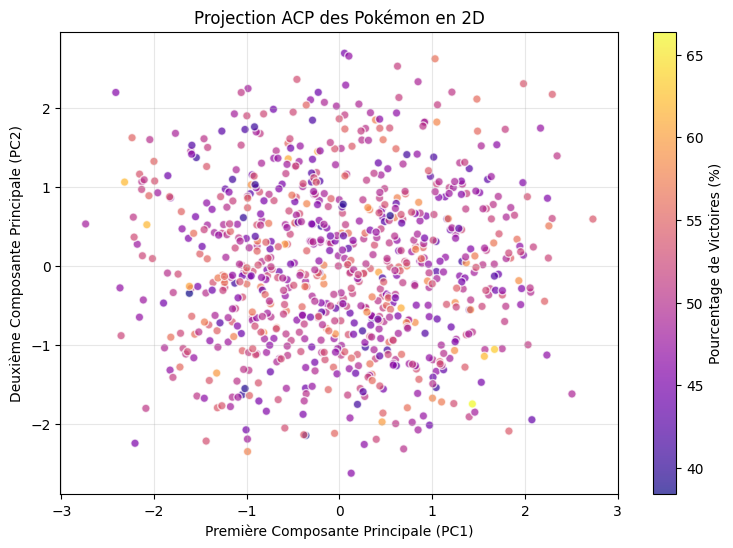

Variance totale expliquée par les 2 premières composantes : 35.95 %


In [2]:
from sklearn.decomposition import PCA

print("\n--- Étape Évoluée : Réduction de dimension par ACP ---")

# 1. Sélection et centrage-réduction des statistiques de base
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
X_stats = pokemon[stats_cols]
X_stats_scaled = StandardScaler().fit_transform(X_stats)

# 2. Application de l'ACP pour obtenir 2 composantes principales
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_stats_scaled)

# 3. Création d'un DataFrame pour la visualisation
df_pca = pd.DataFrame(X_pca, columns=['PC1 (Composante 1)', 'PC2 (Composante 2)'])
df_pca['Legendary'] = pokemon['Legendary'].values
df_pca['Win_Percentage'] = pokemon['Win_Percentage'].values

# 4. Graphique de projection ACP
plt.figure(figsize=(9, 6))
scatter = plt.scatter(df_pca['PC1 (Composante 1)'], df_pca['PC2 (Composante 2)'],
            c=df_pca['Win_Percentage'], cmap='plasma', alpha=0.7, edgecolors='w')
plt.colorbar(scatter, label='Pourcentage de Victoires (%)')
plt.title("Projection ACP des Pokémon en 2D")
plt.xlabel("Première Composante Principale (PC1)")
plt.ylabel("Deuxième Composante Principale (PC2)")
plt.grid(True, alpha=0.3)
plt.show()

print(f"Variance totale expliquée par les 2 premières composantes : {sum(pca.explained_variance_ratio_)*100:.2f} %")
